# Итоговое задание по курсу «Анализ временных рядов»

**Датасет:** Electricity Consumption and Production (Румыния, данные ENTSO-E)
(https://github.com/MVRonkin/TimeSeriesCourse/tree/main/OLD%20Versions/2026/datasets/Electricity%20Consumption%20and%20Production%20Data)

**Целевая переменная:** почасовое потребление электроэнергии Consumption (МВт). Дополнительно в панель включены потребление, суммарная генерация и генерация по 7 источникам (`unique_id` = ряд, `ds` = час, `y` = мощность в МВт).

**Экзогенные признаки:** календарные (час суток, день недели, месяц) известны в будущем, поэтому корректно используются как регрессоры для моделей.

**Горизонт прогноза:** 48 часов (2 суток)

**Структура ноутбука:**
1. **Задача №1** - Подготовка данных и EDA
2. **Задача №2** - Статистические методы (statsforecast: AutoARIMA, AutoETS, AutoTheta, AutoCES, Prophet + ручные ARIMA/ETS)
3. **Задача №3** - ML/DL и детекция аномалий (mlforecast, neuralforecast, IsolationForest/STL/Prophet)
4. **Задача №4** - Пайплайн, тестирование, сравнительная таблица


## 0. Setup

In [4]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip install -q statsforecast mlforecast neuralforecast prophet pyod utilsforecast


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.4/411.4 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 7.0 MB/s eta 0:00:00


In [5]:
import os, warnings, time, json, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
sns.set_style('whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Python  :', sys.version.split()[0])
print('Pandas  :', pd.__version__)
print('NumPy   :', np.__version__)
print('IN_COLAB:', IN_COLAB)


Python  : 3.12.13
Pandas  : 2.2.2
NumPy   : 2.0.2
IN_COLAB: True


---
# Задача №1. Подготовка данных и EDA

**Цель:** загрузить датасет почасового потребления/генерации электроэнергии, привести его к формату панели временных рядов (unique_id, ds, y), провести базовый и временной EDA.

**Подзадачи:**
1.1. Загрузка датасета (один CSV из репозитория курса)
1.2. Разбор структуры и приведение типов
1.3. Преобразование в панель временных рядов (потребление + генерация по источникам)
1.4. Базовый EDA (пропуски, типы, диапазоны)
1.5. EDA временных рядов (декомпозиция, стационарность, ACF/PACF)
1.6. Сохранение подготовленных данных


## 1.1. Загрузка датасета

In [6]:
DATA_URL = (
    'https://raw.githubusercontent.com/MVRonkin/TimeSeriesCourse/main/'
    'OLD%20Versions/2026/datasets/Electricity%20Consumption%20and%20Production%20Data/Electricity.csv'
)
LOCAL_CSV = Path('./Electricity.csv')

if LOCAL_CSV.exists():
    print('Читаю локальную копию:', LOCAL_CSV)
    raw = pd.read_csv(LOCAL_CSV)
else:
    print('Скачиваю из репозитория курса')
    raw = pd.read_csv(DATA_URL)
    raw.to_csv(LOCAL_CSV, index=False)

print('Размер:', raw.shape)
raw.head()


Скачиваю из репозитория курса...
Размер: (46011, 10)


,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


## 1.2. Разбор структуры и приведение типов

Колонки датасета:
1. DateTime: временная метка (час);
2. Consumption: потребление (МВт), главная целевая переменная;
3. Production: суммарная генерация (МВт);
4. Nuclear, Wind, Hydroelectric, Oil and Gas, Coal, Solar, Biomass: генерация по типам источников


In [7]:
raw['DateTime'] = pd.to_datetime(raw['DateTime'])
raw = raw.sort_values('DateTime').reset_index(drop=True)

value_cols = ['Consumption', 'Production', 'Nuclear', 'Wind',
              'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']

# Дубликаты меток времени (переход на зимнее время)
dups = raw['DateTime'].duplicated().sum()
if dups:
    raw = raw.groupby('DateTime', as_index=False)[value_cols].mean()
    print(f'Схлопнуто дубликатов меток времени: {dups}')

print('Период данных :', raw['DateTime'].min(), '→', raw['DateTime'].max())
print('Всего часов   :', len(raw))
print('\nПропуски по колонкам:')
print(raw[value_cols].isna().sum())
raw[value_cols].describe()


Схлопнуто дубликатов меток времени: 9
Период данных : 2019-01-01 00:00:00 → 2024-03-31 23:00:00
Всего часов   : 46002

Пропуски по колонкам:
Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
dtype: int64


,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
count,46002.000000,46002.000000,46002.000000,46002.000000,46002.000000,46002.000000,46002.000000,46002.000000,46002.000000
mean,6587.925050,6518.938807,1291.157182,792.379639,1857.213556,1171.947596,1193.152972,156.718686,55.852246
std,1043.512718,986.662245,236.568160,675.835156,692.558107,434.756914,320.464407,229.514634,14.236460
min,3889.000000,3315.000000,562.000000,-26.000000,175.000000,198.000000,279.000000,0.000000,17.000000
25%,5773.000000,5814.000000,1347.000000,236.000000,1347.000000,858.000000,962.000000,0.000000,45.000000
50%,6552.000000,6462.500000,1383.000000,592.000000,1747.000000,1211.000000,1172.000000,2.000000,57.000000
75%,7321.750000,7176.000000,1405.000000,1205.750000,2265.000000,1511.000000,1406.000000,281.000000,67.000000
max,9615.000000,9886.000000,1457.000000,2811.000000,4434.000000,2141.000000,2537.000000,1137.000000,89.000000


## 1.3. Преобразование в панель временных рядов

Расплавляем широкую таблицу в длинную панель: каждый ряд (Consumption, Production, источники) становится отдельным unique_id. Так все ряды единообразно подаются в statsforecast / mlforecast / neuralforecast.

Чтобы прогон укладывался в разумное время, ограничиваемся последними `N_MONTHS=12` месяцами (около 8760 часов на ряд - этого с запасом хватает для суточной `period=24` и недельной `period=168` сезонности). Полную историю можно включить, увеличив `N_MONTHS`.


In [8]:
N_MONTHS = 6  # окно анализа; 6 мес, 4380 ч/ряд

DATE_TO   = raw['DateTime'].max().floor('D')
DATE_FROM = DATE_TO - pd.DateOffset(months=N_MONTHS)
win = raw[(raw['DateTime'] >= DATE_FROM) & (raw['DateTime'] < DATE_TO)].copy()
print(f'Окно: {DATE_FROM} -> {DATE_TO}  ({len(win)} часов)')

# длинная панель
panel = win.melt(id_vars='DateTime', value_vars=value_cols,
                 var_name='unique_id', value_name='y')
panel = panel.rename(columns={'DateTime': 'ds'})

# гарантируем непрерывную почасовую сетку для каждого ряда; пропуски интерполируем
full_idx = pd.MultiIndex.from_product(
    [value_cols, pd.date_range(DATE_FROM, DATE_TO, freq='h', inclusive='left')],
    names=['unique_id', 'ds']
)
panel = (panel.set_index(['unique_id', 'ds'])
              .reindex(full_idx)
              .reset_index())
panel['y'] = (panel.groupby('unique_id', observed=True)['y']
                    .apply(lambda s: s.interpolate('linear').ffill().bfill())
                    .reset_index(level=0, drop=True))
panel['y'] = panel['y'].clip(lower=0)
panel['unique_id'] = panel['unique_id'].astype('category')

print('Размер панели:', panel.shape)
print('Рядов:', panel['unique_id'].nunique(),
      '| Точек на ряд:', panel.groupby('unique_id', observed=True).size().unique())
panel.head()


Окно: 2023-09-30 00:00:00 → 2024-03-31 00:00:00  (4392 часов)
Размер панели: (39528, 3)
Рядов: 9 | Точек на ряд: [4392]


,unique_id,ds,y
0,Consumption,2023-09-30 00:00:00,5205.0
1,Consumption,2023-09-30 01:00:00,5014.0
2,Consumption,2023-09-30 02:00:00,4879.0
3,Consumption,2023-09-30 03:00:00,4748.0
4,Consumption,2023-09-30 04:00:00,4780.0


## 1.4. Базовый EDA

In [9]:
print('=== info ===')
panel.info()
print('\n=== describe ===')
panel.describe()


=== info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39528 entries, 0 to 39527
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   unique_id  39528 non-null  category      
 1   ds         39528 non-null  datetime64[ns]
 2   y          39528 non-null  float64       
dtypes: category(1), datetime64[ns](1), float64(1)
memory usage: 656.7 KB

=== describe ===


,ds,y
count,39528,39528.000000
mean,2023-12-30 11:30:00,2204.048624
min,2023-09-30 00:00:00,0.000000
25%,2023-11-14 17:45:00,516.750000
50%,2023-12-30 11:30:00,1370.000000
75%,2024-02-14 05:15:00,2286.250000
max,2024-03-30 23:00:00,9235.000000
std,NaN,2455.630981


In [10]:
# Статистика по рядам
stats = (panel.groupby('unique_id', observed=True)['y']
              .agg(['count', 'mean', 'std', 'min', 'max',
                    lambda s: (s == 0).sum()])
              .rename(columns={'<lambda_0>': 'zero_hours'}))
stats


,count,mean,std,min,max,zero_hours
unique_id,,,,,,
Biomass,4392,51.742486,9.246292,27.0,72.0,0
Coal,4392,858.787113,133.115787,424.0,1418.0,0
Consumption,4392,6396.854167,980.274389,4316.0,8764.0,0
Hydroelectric,4392,1833.672587,491.795700,566.0,3787.0,0
Nuclear,4392,1347.256831,138.968789,624.0,1407.0,0
Oil and Gas,4392,1537.131831,240.887738,475.0,1960.0,0
Production,4392,6722.693306,918.074642,4213.0,9235.0,0
Solar,4392,128.845401,221.905497,0.0,1137.0,2459
Wind,4392,959.453893,684.721961,0.0,2751.0,6


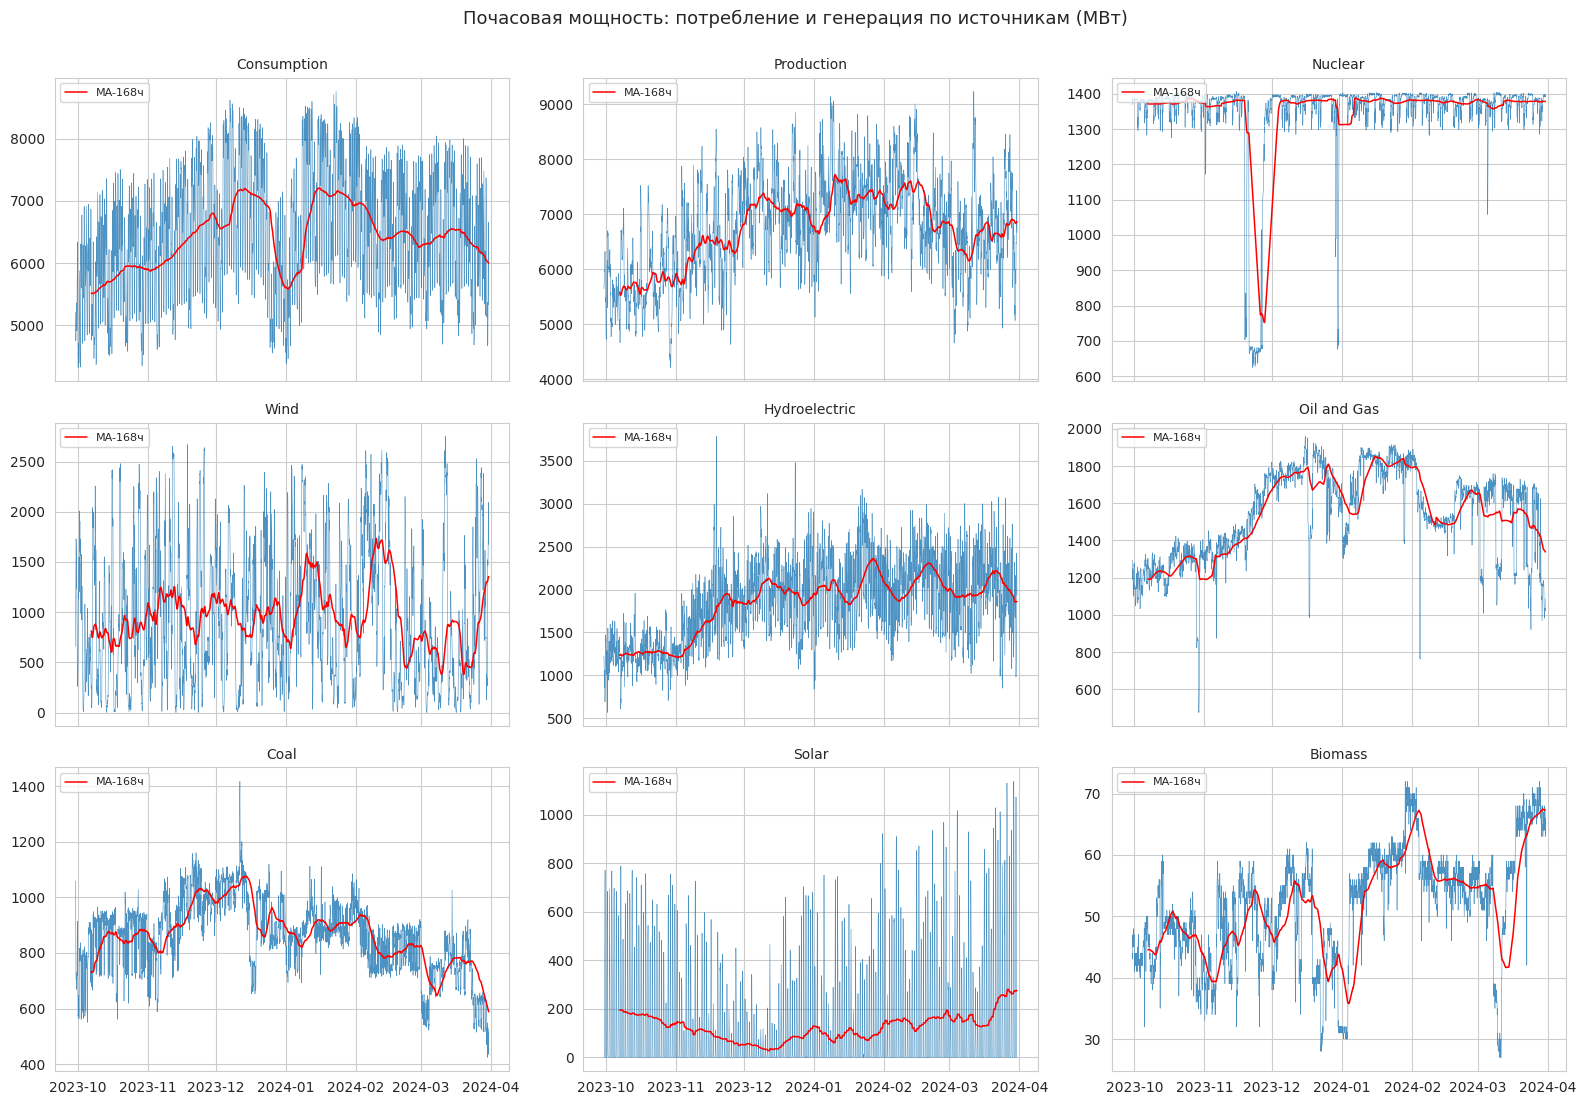

In [11]:
# === График всех 9 рядов ===
fig, axes = plt.subplots(3, 3, figsize=(16, 11), sharex=True)
for ax, uid in zip(axes.ravel(), value_cols):
    s = panel[panel['unique_id'] == uid].set_index('ds')['y']
    ax.plot(s.index, s.values, linewidth=0.4, alpha=0.8)
    ax.plot(s.index, s.rolling(168).mean(), color='red', linewidth=1.1, label='MA-168ч')
    ax.set_title(uid, fontsize=10)
    ax.legend(loc='upper left', fontsize=8)
fig.suptitle('Почасовая мощность: потребление и генерация по источникам (МВт)', y=1.00, fontsize=13)
fig.tight_layout()
plt.show()


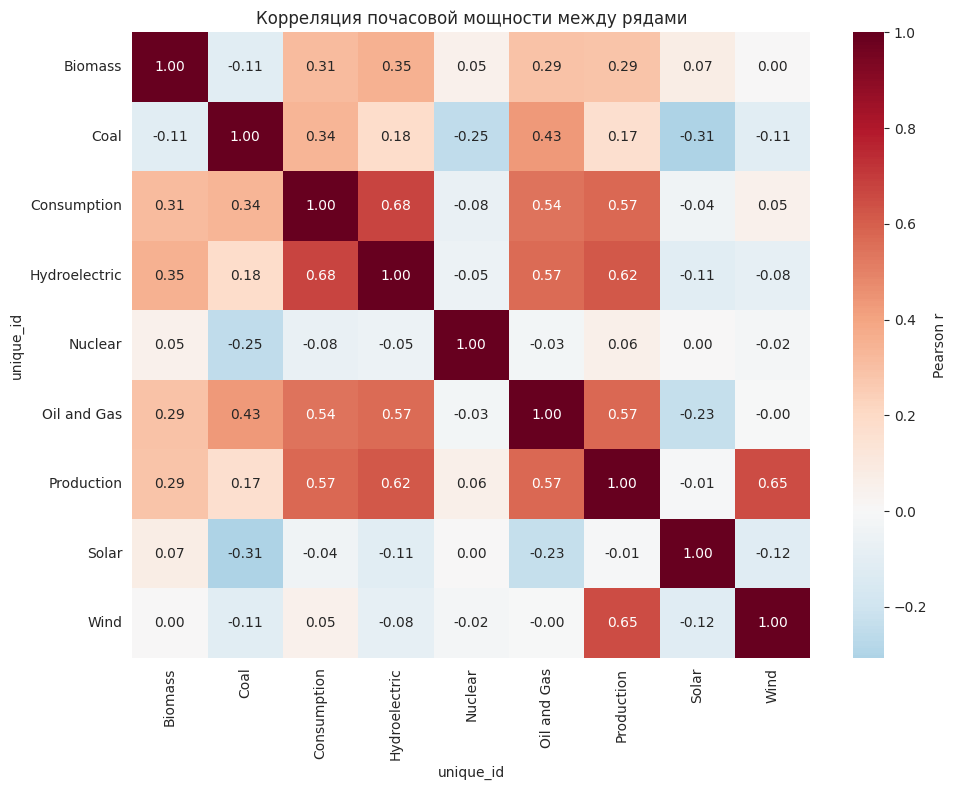

In [12]:
# Кросс-корреляция рядов (баланс потребление/генерация)
wide = panel.pivot(index='ds', columns='unique_id', values='y')
corr = wide.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Pearson r'})
plt.title('Корреляция почасовой мощности между рядами')
plt.tight_layout()
plt.show()


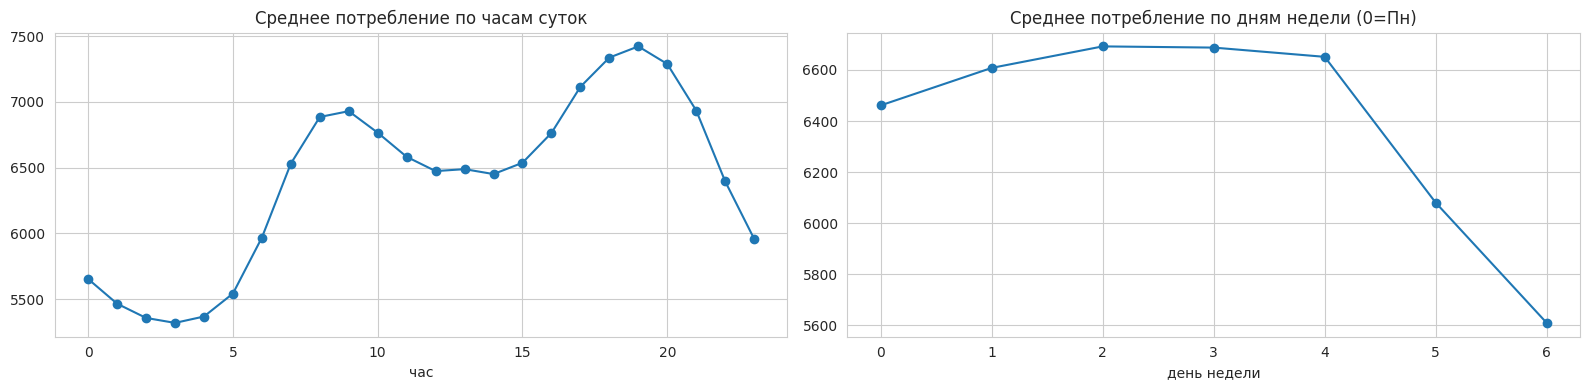

In [13]:
# Профиль суточной/недельной сезонности потребления
cons = panel[panel['unique_id'] == 'Consumption'].set_index('ds')['y']
prof = pd.DataFrame({'y': cons})
prof['hour'] = prof.index.hour
prof['dow']  = prof.index.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
prof.groupby('hour')['y'].mean().plot(ax=axes[0], marker='o')
axes[0].set_title('Среднее потребление по часам суток'); axes[0].set_xlabel('час')
prof.groupby('dow')['y'].mean().plot(ax=axes[1], marker='o')
axes[1].set_title('Среднее потребление по дням недели (0=Пн)'); axes[1].set_xlabel('день недели')
plt.tight_layout(); plt.show()

## 1.5. EDA временных рядов

Для подробного анализа берём главный ряд - `Consumption` и проверяем: тренд, сезонность (суточная/недельная), стационарность, автокорреляцию.


In [14]:
TARGET_UID = 'Consumption'
ts = panel[panel['unique_id'] == TARGET_UID].set_index('ds')['y']
print(f'Анализируем: {TARGET_UID} (n={len(ts)})')


Анализируем: Consumption (n=4392)


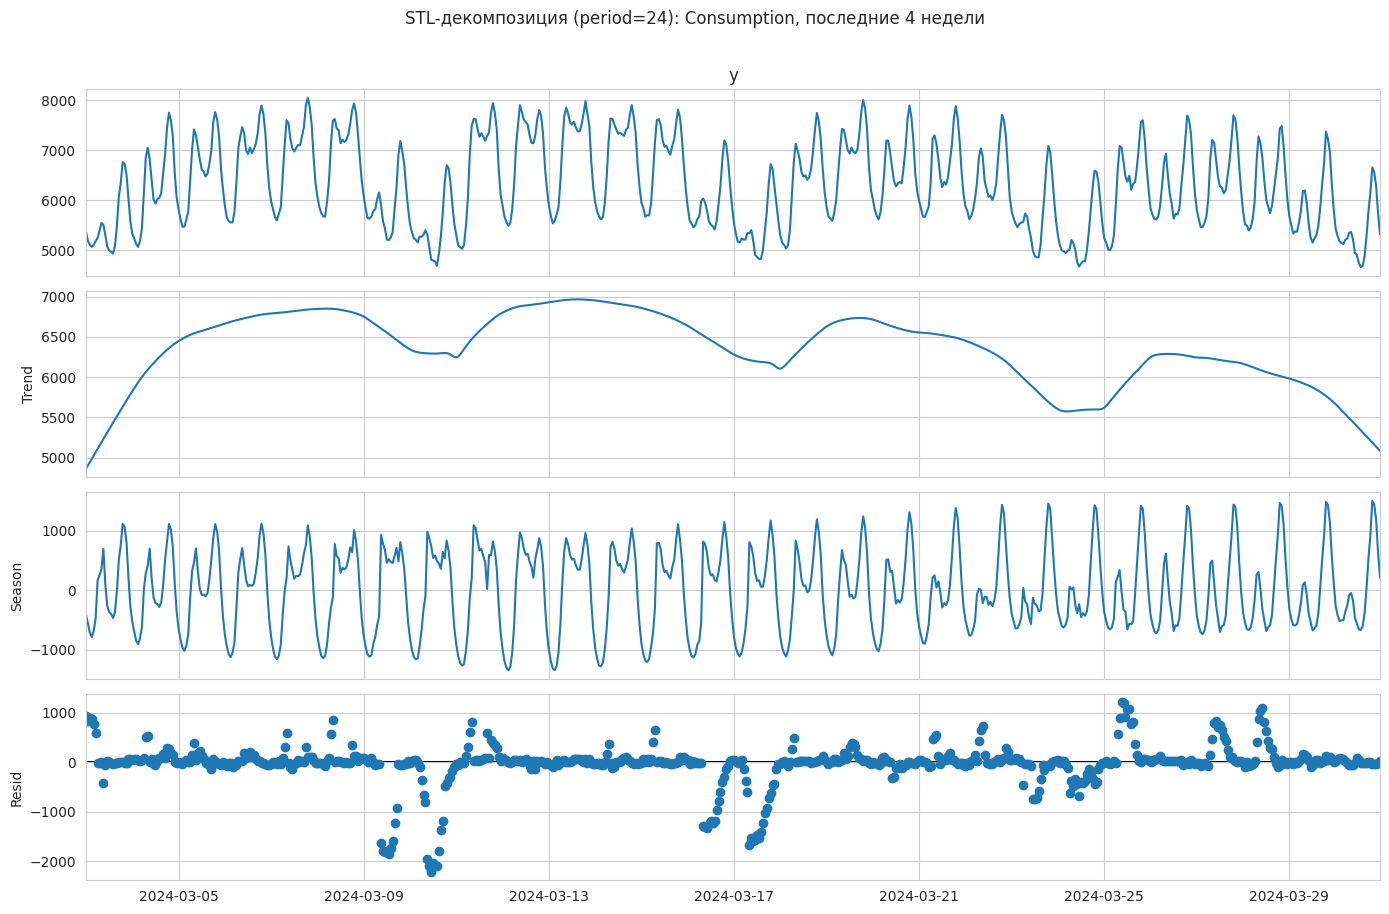

In [15]:
# STL декомпозиция (суточная сезонность, period=24)
from statsmodels.tsa.seasonal import STL

# для наглядности декомпозируем фрагмент еще и в 4 недели
ts_seg = ts.iloc[-24*28:]
stl = STL(ts_seg, period=24, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(14, 9)
fig.suptitle(f'STL-декомпозиция (period=24): {TARGET_UID}, последние 4 недели', y=1.01)
plt.tight_layout()
plt.show()


In [16]:
# Тесты стационарности
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_report(s, name=''):
    s = s.dropna()
    adf = adfuller(s, autolag='AIC')
    try:
        kp = kpss(s, regression='c', nlags='auto')
    except Exception:
        kp = (np.nan, np.nan)
    print(f'--- {name} ---')
    print(f'  ADF  statistic = {adf[0]:8.3f}  p-value = {adf[1]:.4f}  '
          f'-> {"стационарен" if adf[1] < 0.05 else "НЕ стационарен"} (H0: единичный корень)')
    print(f'  KPSS statistic = {kp[0]:8.3f}  p-value = {kp[1]:.4f}  '
          f'-> {"стационарен" if kp[1] > 0.05 else "НЕ стационарен"} (H0: стационарность)')

stationarity_report(ts, 'Исходный ряд')
stationarity_report(ts.diff(), 'Первая разность')
stationarity_report(ts.diff(24), 'Сезонная разность (24ч)')


/tmp/ipykernel_496/1048567800.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_496/1048567800.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(s, regression='c', nlags='auto')


--- Исходный ряд ---
  ADF  statistic =   -6.244  p-value = 0.0000  -> стационарен (H0: единичный корень)
  KPSS statistic =    1.683  p-value = 0.0100  -> НЕ стационарен (H0: стационарность)
--- Первая разность ---
  ADF  statistic =  -12.340  p-value = 0.0000  -> стационарен (H0: единичный корень)
  KPSS statistic =    0.017  p-value = 0.1000  -> стационарен (H0: стационарность)
--- Сезонная разность (24ч) ---
  ADF  statistic =  -10.668  p-value = 0.0000  -> стационарен (H0: единичный корень)
  KPSS statistic =    0.037  p-value = 0.1000  -> стационарен (H0: стационарность)


/tmp/ipykernel_496/1048567800.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(s, regression='c', nlags='auto')


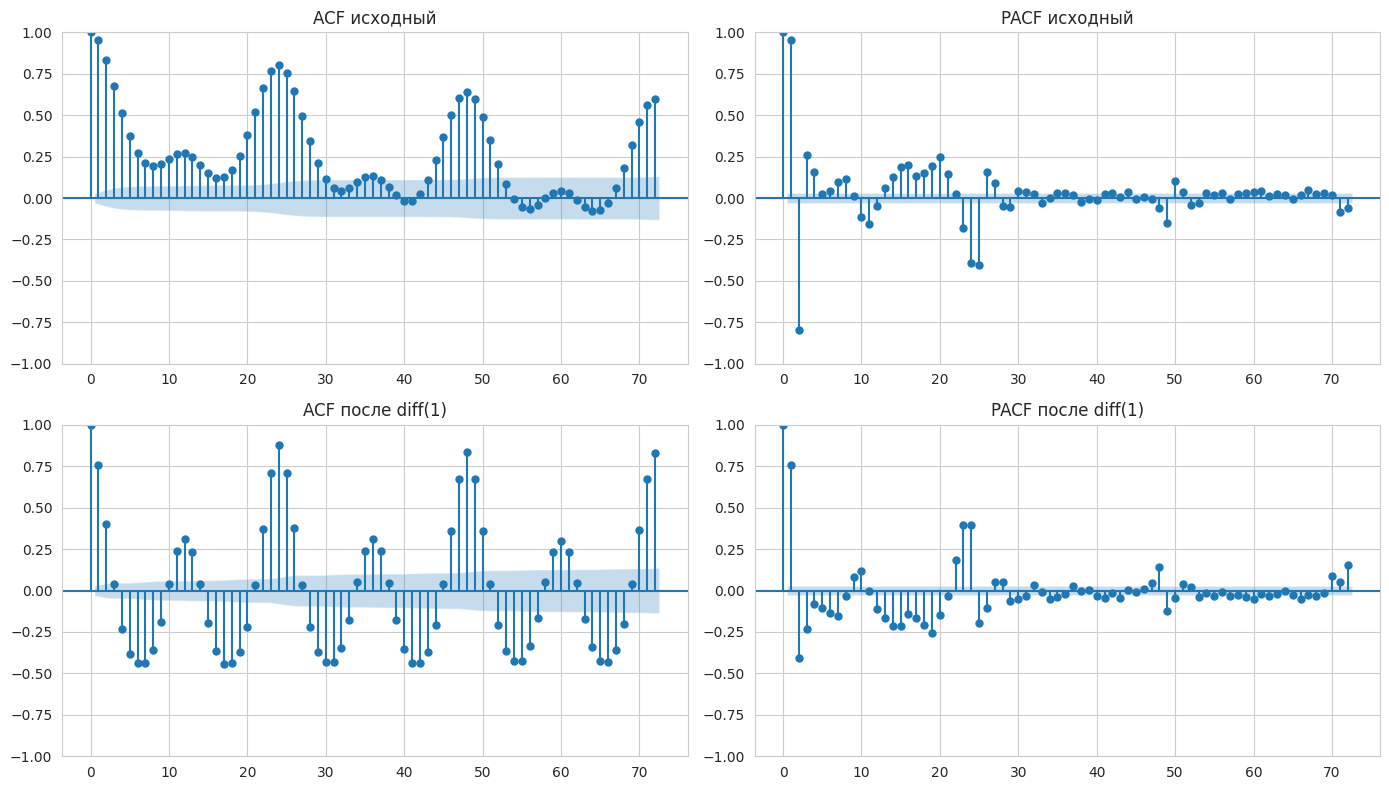

In [17]:
# ACF/PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

LAGS = 72  # 3 суток
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(ts.dropna(),  lags=LAGS, ax=axes[0, 0]); axes[0, 0].set_title('ACF исходный')
plot_pacf(ts.dropna(), lags=LAGS, ax=axes[0, 1], method='ywm'); axes[0, 1].set_title('PACF исходный')
plot_acf(ts.diff().dropna(),  lags=LAGS, ax=axes[1, 0]); axes[1, 0].set_title('ACF после diff(1)')
plot_pacf(ts.diff().dropna(), lags=LAGS, ax=axes[1, 1], method='ywm'); axes[1, 1].set_title('PACF после diff(1)')
plt.tight_layout()
plt.show()


**Выводы EDA:**
- Выраженная **суточная сезонность** (`period=24`): вечерний пик потребления (20:00) и ночной минимум (03:00).
- Дополнительно недельная сезонность (`period=168`): будни выше выходных — видно в ACF на лагах, кратных 24 и 168.
- Возможен годовой паттерн (отопление/кондиционирование), но на 6-месячном окне (осень–зима–начало весны) полный годовой цикл не наблюдается.
- Стационарность: из-за сильной суточной сезонности `ADF` отвергает единичный корень (статистика −6.24, `p = 0.0000` -> стационарен), тогда как `KPSS` указывает на нестационарность относительно тренда (статистика 1.68, `p = 0.01`) — типичная для нагрузки картина. Сезонное дифференцирование `diff(24)` стабилизирует ряд и помогает SARIMA.
- В ACF видны пики на лагах 24, 48, 168 -> нужна сезонная компонента (SARIMA / seasonal-модели).
- Ряды генерации коррелируют с потреблением (`Consumption`~`Production` ≈ 0.55), источники между собой — по-разному → общая суточная динамика оправдывает **глобальные модели** на панели.

## 1.6. Сохранение подготовленных данных

In [18]:
ARTIFACTS = Path('./artifacts')
ARTIFACTS.mkdir(exist_ok=True)

panel.to_parquet(ARTIFACTS / 'panel.parquet', index=False)
panel.to_csv(ARTIFACTS / 'panel.csv', index=False)

with open(ARTIFACTS / 'meta.json', 'w', encoding='utf-8') as f:
    json.dump({
        'dataset': 'MVRonkin/TimeSeriesCourse — Electricity Consumption and Production (Romania, ENTSO-E)',
        'target': 'hourly electricity consumption & generation (MW)',
        'main_series': 'Consumption',
        'freq': 'h',
        'date_from': str(DATE_FROM),
        'date_to':   str(DATE_TO),
        'horizon_hours': 48,
        'season_length': 24,
        'unique_ids': value_cols,
        'n_series': len(value_cols),
        'series_length': int(panel.groupby('unique_id', observed=True).size().iloc[0]),
    }, f, ensure_ascii=False, indent=2)

print('Сохранено в', ARTIFACTS.resolve())
!ls -la {ARTIFACTS}


Сохранено в /content/artifacts
total 1520
drwxr-xr-x 2 root root    4096 Jun  7 13:41 .
drwxr-xr-x 1 root root    4096 Jun  7 13:41 ..
-rw-r--r-- 1 root root     545 Jun  7 13:41 meta.json
-rw-r--r-- 1 root root 1397250 Jun  7 13:41 panel.csv
-rw-r--r-- 1 root root  140210 Jun  7 13:41 panel.parquet


---
# Задача №2. Статистические методы (statsforecast)

**Цель:** обоснованно сравнить ≥ 5 статистических методов прогнозирования ВР, включая ручной и автоматический режимы, бектестинг, вероятностные прогнозы и анализ остатков.

**Что используем:**
- **Baseline:** `Naive`, `SeasonalNaive(24)`, `HistoricAverage`, `WindowAverage(168)`
- **Авто:** `AutoARIMA`, `AutoETS`, `AutoTheta`, `AutoCES`
- **Ручные:** `ARIMA(p,d,q)(P,D,Q)_24`, `ETS(A,A,A)`
- **Отдельно:** `Prophet` (через прямое API)
- **Бектестинг:** `cross_validation` на 3 окнах по 48 часов
- **Вероятностные прогнозы:** уровни 80% и 95%
- **Анализ остатков:** Ljung-Box, ACF остатков, QQ-plot

## 2.1. Train/test split и метрики

In [19]:
HORIZON = 48          # 48 часов
FREQ = 'h'
SEASON_LENGTH = 24    # суточная сезонность

cutoff = panel['ds'].max() - pd.Timedelta(hours=HORIZON)
train = panel[panel['ds'] <= cutoff].copy()
test  = panel[panel['ds'] >  cutoff].copy()

print(f'Train: {train["ds"].min()} - {train["ds"].max()}  '
      f'({train["ds"].nunique()} часов)')
print(f'Test : {test["ds"].min()} - {test["ds"].max()}  '
      f'({test["ds"].nunique()} часов)')


Train: 2023-09-30 00:00:00 - 2024-03-28 23:00:00  (4344 часов)
Test : 2024-03-29 00:00:00 - 2024-03-30 23:00:00  (48 часов)


In [20]:
# Метрики
def mae(y, yhat):  return np.mean(np.abs(y - yhat))
def rmse(y, yhat): return np.sqrt(np.mean((y - yhat) ** 2))
def mape(y, yhat, eps=1e-6):  return np.mean(np.abs((y - yhat) / np.maximum(np.abs(y), eps))) * 100
def smape(y, yhat, eps=1e-6): return np.mean(2 * np.abs(y - yhat) / np.maximum(np.abs(y) + np.abs(yhat), eps)) * 100

def score(forecast_df, test_df, model_cols):
    """Сводная таблица метрик по моделям, усреднение по всем unique_id."""
    merged = forecast_df.merge(test_df[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'])
    rows = []
    for col in model_cols:
        y, yhat = merged['y'].values, merged[col].values
        rows.append({'model': col,
                     'MAE':  mae(y, yhat),
                     'RMSE': rmse(y, yhat),
                     'MAPE': mape(y, yhat),
                     'sMAPE': smape(y, yhat)})
    return pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)


## 2.2. Baseline и авто-модели statsforecast

In [21]:
from statsforecast import StatsForecast
from statsforecast.models import (
      Naive, SeasonalNaive, HistoricAverage, WindowAverage,
      AutoARIMA, AutoETS, AutoTheta, AutoCES,
      ARIMA,
  )
from statsforecast.utils import ConformalIntervals

# Конформные интервалы, нужны моделям без аналитических PI для level=[80,95]
ci = ConformalIntervals(n_windows=2, h=HORIZON)

def make_autoarima(alias=None):
      return AutoARIMA(season_length=SEASON_LENGTH, approximation=True, stepwise=True,
                       max_p=3, max_q=3, max_P=1, max_Q=1, max_d=1, max_D=1,
                       prediction_intervals=ci,
                       **({'alias': alias} if alias else {}))

models_stat = [
      Naive(prediction_intervals=ci),
      SeasonalNaive(season_length=SEASON_LENGTH, prediction_intervals=ci),
      HistoricAverage(prediction_intervals=ci),
      WindowAverage(window_size=168, prediction_intervals=ci),
      make_autoarima(),
      AutoETS(season_length=SEASON_LENGTH, prediction_intervals=ci),
      AutoTheta(season_length=SEASON_LENGTH, prediction_intervals=ci),
      AutoCES(season_length=SEASON_LENGTH, prediction_intervals=ci),
      # ручные конфигурации:
      ARIMA(order=(2, 1, 1), season_length=SEASON_LENGTH, seasonal_order=(1, 0, 0),
            prediction_intervals=ci, alias='ARIMA_manual'),
      AutoETS(model='AAA', season_length=SEASON_LENGTH, prediction_intervals=ci,
  alias='ETS_manual'),
  ]

sf = StatsForecast(models=models_stat, freq=FREQ, n_jobs=-1)


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7e92a6d64680>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.12/dist-packages/scipy.libs/libscipy_openblas-b75cc656.

In [22]:
%%time
sf.fit(df=train)
forecast_stat = sf.predict(h=HORIZON, level=[80, 95])
forecast_stat.head()


CPU times: user 120 ms, sys: 145 ms, total: 265 ms
Wall time: 15min 41s


,unique_id,ds,Naive,Naive-lo-95,Naive-lo-80,Naive-hi-80,Naive-hi-95,SeasonalNaive,SeasonalNaive-lo-95,SeasonalNaive-lo-80,SeasonalNaive-hi-80,SeasonalNaive-hi-95,HistoricAverage,HistoricAverage-lo-95,HistoricAverage-lo-80,HistoricAverage-hi-80,HistoricAverage-hi-95,WindowAverage,WindowAverage-lo-95,WindowAverage-lo-80,WindowAverage-hi-80,WindowAverage-hi-95,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-lo-80,AutoARIMA-hi-80,AutoARIMA-hi-95,AutoETS,AutoETS-lo-95,AutoETS-lo-80,AutoETS-hi-80,AutoETS-hi-95,AutoTheta,AutoTheta-lo-80,AutoTheta-hi-80,AutoTheta-lo-95,AutoTheta-hi-95,CES,CES-lo-95,CES-lo-80,CES-hi-80,CES-hi-95,ARIMA_manual,ARIMA_manual-lo-95,ARIMA_manual-lo-80,ARIMA_manual-hi-80,ARIMA_manual-hi-95,ETS_manual,ETS_manual-lo-95,ETS_manual-lo-80,ETS_manual-hi-80,ETS_manual-hi-95
0,Biomass,2024-03-29 00:00:00,66.0,65.075,65.3,66.7,66.925,68.0,66.075,66.3,69.7,69.925,51.588858,36.888920,37.156337,66.021380,66.288797,67.089286,65.750744,65.985119,68.193452,68.427827,66.373414,65.165266,65.449848,67.296980,67.581561,66.118172,65.083029,65.312988,66.923356,67.153314,65.661765,65.086217,66.237314,65.024248,66.299283,65.656752,65.045403,65.171818,66.141686,66.268101,66.384069,65.177185,65.459373,67.308765,67.590953,67.643735,65.715911,66.034737,69.252734,69.571560
1,Biomass,2024-03-29 01:00:00,66.0,66.000,66.0,66.0,66.000,68.0,67.075,67.3,68.7,68.925,51.588858,36.813920,36.856337,66.321380,66.363797,67.089286,66.675744,66.685119,67.493452,67.502827,66.663787,66.184023,66.300675,67.026899,67.143550,66.118172,66.008029,66.012988,66.223356,66.228314,65.487819,64.935072,66.040567,64.925538,66.050101,65.429748,64.978037,65.077227,65.782268,65.881458,66.687629,66.198641,66.304229,67.071028,67.176616,67.763571,66.854285,66.882944,68.644199,68.672858
2,Biomass,2024-03-29 02:00:00,66.0,65.075,65.3,66.7,66.925,67.0,66.075,66.3,67.7,67.925,51.588858,36.049161,36.231744,66.945972,67.128556,67.089286,66.521577,66.568452,67.610119,67.656994,66.769633,66.413685,66.487414,67.051852,67.125580,66.118172,65.289850,65.469501,66.766842,66.946493,65.194641,63.661881,66.727402,63.447017,66.942265,65.434665,63.852148,64.235585,66.633744,67.017181,66.811000,66.484796,66.561601,67.060399,67.137204,68.125198,67.633906,67.726811,68.523584,68.616489
3,Biomass,2024-03-29 03:00:00,66.0,66.000,66.0,66.0,66.000,69.0,66.075,66.3,71.7,71.925,51.588858,36.813920,36.856337,66.321380,66.363797,67.089286,66.675744,66.685119,67.493452,67.502827,66.964592,66.242495,66.395308,67.533876,67.686689,66.118172,66.008029,66.012988,66.223356,66.228314,65.787686,65.528515,66.046857,65.517407,66.057966,65.609266,65.305012,65.365814,65.852717,65.913519,66.982717,66.242110,66.406485,67.558949,67.723323,68.824130,66.969744,67.318784,70.329476,70.678516
4,Biomass,2024-03-29 04:00:00,66.0,65.000,65.0,67.0,67.000,69.0,68.075,68.3,69.7,69.925,51.588858,35.813920,35.856337,67.321380,67.363797,67.089286,65.773661,65.951786,68.226786,68.404911,67.054464,66.132043,66.296957,67.811971,67.976885,66.118172,65.209582,65.214541,67.021803,67.026761,65.561991,64.071734,67.052248,64.061422,67.062560,65.420067,63.954372,64.042370,66.797763,66.885761,67.026110,66.071373,66.241452,67.810769,67.980848,68.735112,67.907321,67.936823,69.533402,69.562904


In [23]:
model_names_stat = [m.alias for m in models_stat]
scores_stat = score(forecast_stat.reset_index(), test, model_names_stat)
scores_stat


,model,MAE,RMSE,MAPE,sMAPE
0,ARIMA_manual,248.398516,407.280246,3.903026e+08,28.601483
1,Naive,330.868056,492.856407,2.563572e+01,28.973869
2,AutoTheta,312.766957,498.411919,3.058463e+05,33.123064
3,CES,322.678381,500.126251,2.303707e+05,22.731461
4,WindowAverage,352.303351,520.138480,1.277402e+09,32.506612
5,AutoARIMA,320.743972,536.884428,9.259483e+05,19.207908
6,ETS_manual,327.187079,538.760636,5.674034e+07,28.179882
7,HistoricAverage,390.484873,547.325124,6.149116e+08,40.532871
8,AutoETS,370.450301,568.700223,2.692782e+01,34.697670
9,SeasonalNaive,381.266204,634.837357,9.259589e+05,21.758682


## 2.3. Prophet

In [24]:
from prophet import Prophet
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

def prophet_forecast(train_df, horizon=HORIZON):
    parts = []
    for uid, g in train_df.groupby('unique_id', observed=True):
        g = g[['ds', 'y']].sort_values('ds')
        m = Prophet(daily_seasonality=True, weekly_seasonality=True,
                    yearly_seasonality=False, interval_width=0.95)
        m.fit(g)
        future = m.make_future_dataframe(periods=horizon, freq='h')
        f = m.predict(future).tail(horizon)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
        f['unique_id'] = uid
        parts.append(f)
    return pd.concat(parts, ignore_index=True).rename(
        columns={'yhat': 'Prophet', 'yhat_lower': 'Prophet-lo-95', 'yhat_upper': 'Prophet-hi-95'}
    )

t0 = time.time()
forecast_prophet = prophet_forecast(train, HORIZON)
print(f'Prophet: {time.time()-t0:.1f}s')
forecast_prophet.head()


Prophet: 14.6s


,ds,Prophet,Prophet-lo-95,Prophet-hi-95,unique_id
0,2024-03-29 00:00:00,63.411559,51.275664,75.013781,Biomass
1,2024-03-29 01:00:00,63.205095,50.379051,74.805073,Biomass
2,2024-03-29 02:00:00,63.168554,50.725271,75.383782,Biomass
3,2024-03-29 03:00:00,63.205235,50.881709,74.211116,Biomass
4,2024-03-29 04:00:00,63.246816,51.249671,75.460122,Biomass


In [25]:
scores_prophet = score(forecast_prophet, test, ['Prophet'])
scores_stat_full = pd.concat([scores_stat, scores_prophet]).sort_values('RMSE').reset_index(drop=True)
scores_stat_full


,model,MAE,RMSE,MAPE,sMAPE
0,ARIMA_manual,248.398516,407.280246,3.903026e+08,28.601483
1,Prophet,319.821501,485.463807,4.618617e+08,31.723662
2,Naive,330.868056,492.856407,2.563572e+01,28.973869
3,AutoTheta,312.766957,498.411919,3.058463e+05,33.123064
4,CES,322.678381,500.126251,2.303707e+05,22.731461
5,WindowAverage,352.303351,520.138480,1.277402e+09,32.506612
6,AutoARIMA,320.743972,536.884428,9.259483e+05,19.207908
7,ETS_manual,327.187079,538.760636,5.674034e+07,28.179882
8,HistoricAverage,390.484873,547.325124,6.149116e+08,40.532871
9,AutoETS,370.450301,568.700223,2.692782e+01,34.697670


## 2.4. Бектестинг (cross_validation на 3 окнах)

In [26]:
%%time
cv_stat = sf.cross_validation(
    df=panel,
    h=HORIZON,
    step_size=HORIZON,
    n_windows=3,
    level=[80, 95],
)
cv_stat.head()


CPU times: user 88.7 ms, sys: 59.5 ms, total: 148 ms
Wall time: 45min 6s


,unique_id,ds,cutoff,y,Naive,Naive-lo-95,Naive-lo-80,Naive-hi-80,Naive-hi-95,SeasonalNaive,SeasonalNaive-lo-95,SeasonalNaive-lo-80,SeasonalNaive-hi-80,SeasonalNaive-hi-95,HistoricAverage,HistoricAverage-lo-95,HistoricAverage-lo-80,HistoricAverage-hi-80,HistoricAverage-hi-95,WindowAverage,WindowAverage-lo-95,WindowAverage-lo-80,WindowAverage-hi-80,WindowAverage-hi-95,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-lo-80,AutoARIMA-hi-80,AutoARIMA-hi-95,AutoETS,AutoETS-lo-95,AutoETS-lo-80,AutoETS-hi-80,AutoETS-hi-95,AutoTheta,AutoTheta-lo-80,AutoTheta-hi-80,AutoTheta-lo-95,AutoTheta-hi-95,CES,CES-lo-95,CES-lo-80,CES-hi-80,CES-hi-95,ARIMA_manual,ARIMA_manual-lo-95,ARIMA_manual-lo-80,ARIMA_manual-hi-80,ARIMA_manual-hi-95,ETS_manual,ETS_manual-lo-95,ETS_manual-lo-80,ETS_manual-hi-80,ETS_manual-hi-95
0,Biomass,2024-03-25 00:00:00,2024-03-24 23:00:00,66.0,66.0,65.000,65.0,67.0,67.000,67.0,62.300,63.2,70.8,71.700,51.210923,37.310537,37.499378,64.922467,65.111309,65.625,63.035863,63.28631,67.96369,68.214137,65.961799,64.959743,65.078915,66.844684,66.963856,66.089758,64.992019,64.994040,67.185475,67.187497,65.617243,64.976230,66.258256,64.969158,66.265327,66.091644,65.505971,65.516319,66.666970,66.677318,65.953221,64.906310,65.088079,66.818362,67.000131,65.382904,62.222066,62.647724,68.118083,68.543741
1,Biomass,2024-03-25 01:00:00,2024-03-24 23:00:00,66.0,66.0,66.000,66.0,66.0,66.000,66.0,58.525,60.1,71.9,73.475,51.210923,36.310537,36.499378,65.922467,66.111309,65.625,62.035863,62.28631,68.96369,69.214137,66.000196,65.292047,65.407929,66.592464,66.708346,66.089758,65.992019,65.994040,66.185475,66.187497,65.434540,64.879341,65.989739,64.870621,65.998460,66.043930,65.323786,65.334775,66.753085,66.764074,65.945096,64.916011,65.094312,66.795880,66.974182,65.208532,61.080964,61.987518,68.429545,69.336099
2,Biomass,2024-03-25 02:00:00,2024-03-24 23:00:00,66.0,66.0,64.150,64.6,67.4,67.850,67.0,62.225,62.9,71.1,71.775,51.210923,35.173939,35.435097,66.986748,67.247907,65.625,60.185863,60.88631,70.36369,71.064137,66.052841,64.371241,64.586700,67.518983,67.734442,66.089758,64.324083,64.731819,67.447697,67.855433,65.135702,62.867859,67.403546,62.420391,67.851014,65.993835,63.425978,63.880418,68.107253,68.561693,66.010450,64.383646,64.506129,67.514772,67.637255,66.109350,62.969029,63.418130,68.800569,69.249670
3,Biomass,2024-03-25 03:00:00,2024-03-24 23:00:00,66.0,66.0,64.075,64.3,67.7,67.925,68.0,63.300,64.2,71.8,72.700,51.210923,35.098939,35.135097,67.286748,67.322907,65.625,60.110863,60.58631,70.66369,71.139137,66.093864,64.225523,64.275473,67.912255,67.962205,66.089758,64.262497,64.485475,67.694040,67.917019,65.726017,63.737560,67.714475,63.513333,67.938702,65.945709,63.465903,63.685545,68.205873,68.425515,66.064844,63.946820,64.079140,68.050548,68.182868,66.419443,62.323934,62.945862,69.893025,70.514952
4,Biomass,2024-03-25 04:00:00,2024-03-24 23:00:00,67.0,66.0,63.150,63.6,68.4,68.850,66.0,62.150,62.6,69.4,69.850,51.210923,34.173939,34.435097,67.986748,68.247907,65.625,59.185863,59.88631,71.36369,72.064137,66.022607,63.452314,63.604737,68.440478,68.592901,66.089758,63.337497,63.785475,68.394040,68.842019,65.495994,62.578260,68.413727,62.126685,68.865302,65.896072,62.336434,62.784883,69.007261,69.455711,65.988569,63.469562,63.556477,68.420661,68.507576,66.162375,62.213040,62.559772,69.764978,70.111710


In [27]:
# Метрики по каждому фолду + усреднение
cv_long = cv_stat.reset_index().melt(
    id_vars=['unique_id', 'ds', 'cutoff', 'y'],
    value_vars=model_names_stat,
    var_name='model', value_name='yhat'
)
cv_summary = (cv_long.groupby(['model', 'cutoff'])
              .apply(lambda d: pd.Series({
                  'MAE':  mae(d['y'].values, d['yhat'].values),
                  'RMSE': rmse(d['y'].values, d['yhat'].values),
                  'sMAPE': smape(d['y'].values, d['yhat'].values),
              }))
              .reset_index())
cv_mean = cv_summary.groupby('model')[['MAE', 'RMSE', 'sMAPE']].agg(['mean', 'std']).round(2)
cv_mean.sort_values(('RMSE', 'mean'))


MAE            RMSE          sMAPE      
                   mean     std    mean     std   mean   std
model                                                       
AutoTheta        301.93   61.75  501.02  101.72  30.23  4.19
HistoricAverage  371.45   16.49  544.38    7.92  38.17  2.15
AutoETS          348.81   76.47  546.57  108.63  28.77  5.82
WindowAverage    359.86   23.09  550.98   49.12  32.25  2.31
Naive            354.46   64.42  552.07  115.84  27.35  2.44
CES              345.22   43.30  558.31   97.19  23.78  2.14
ETS_manual       344.47  113.77  571.08  160.30  28.90  3.72
AutoARIMA        346.05   78.52  587.33  120.70  22.39  8.01
ARIMA_manual     356.10  114.46  588.27  187.14  29.55  2.92
SeasonalNaive    372.92   94.37  649.23  124.89  20.46  2.95

## 2.5. Вероятностные прогнозы (визуализация)

Лучшая стат-модель: ARIMA_manual


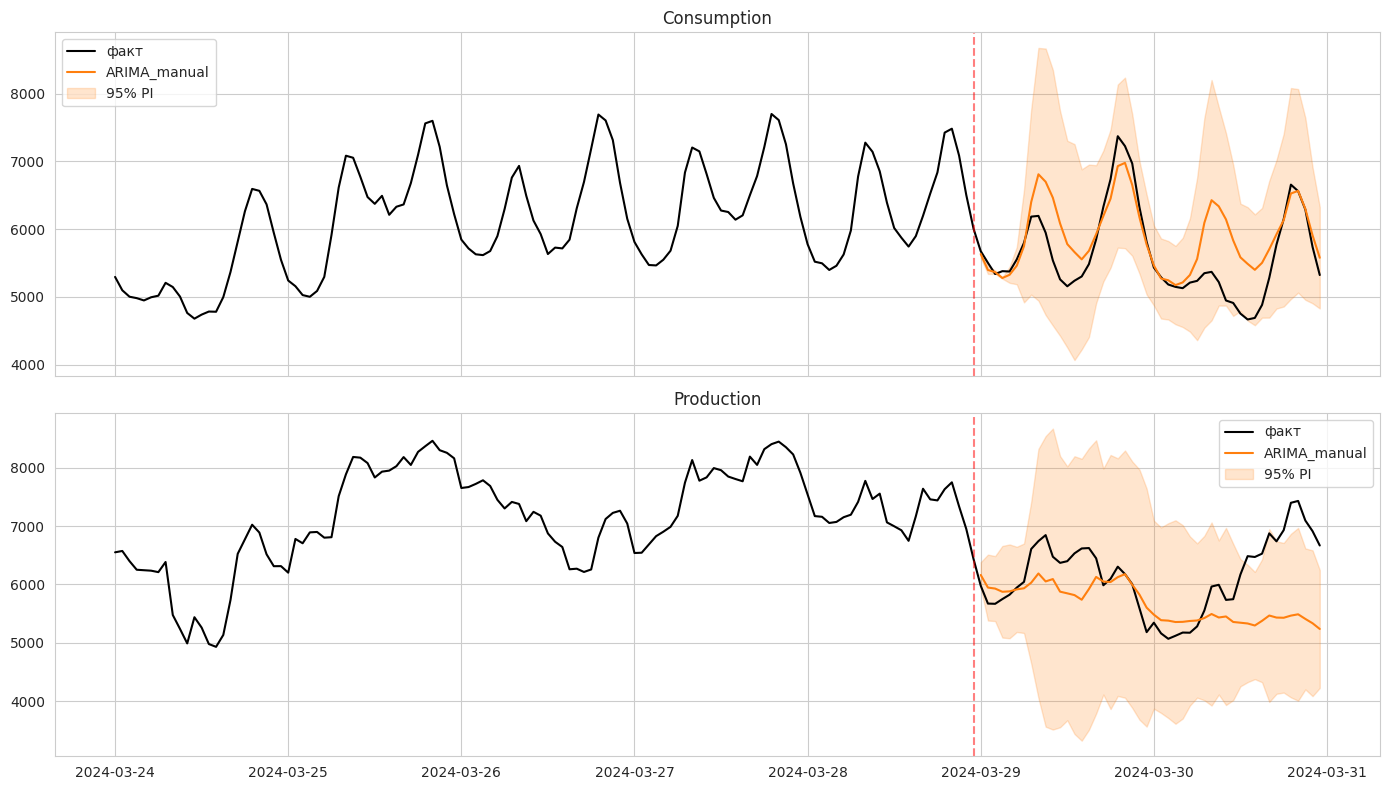

In [28]:
# Картинка для потребления + ещё одного ряда: лучший метод + интервал 95%
BEST_STAT = scores_stat_full.iloc[0]['model']
print('Лучшая стат-модель:', BEST_STAT)

show_ids = ['Consumption', 'Production']
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, uid in zip(axes, show_ids):
    hist = panel[panel['unique_id'] == uid].set_index('ds')['y'].tail(24*7)  # последняя неделя
    fc = forecast_stat.reset_index()
    fc = fc[fc['unique_id'] == uid].set_index('ds')
    ax.plot(hist.index, hist.values, label='факт', color='black')
    ax.plot(fc.index, fc[BEST_STAT], label=f'{BEST_STAT}', color='C1')
    lo_col = f'{BEST_STAT}-lo-95'
    hi_col = f'{BEST_STAT}-hi-95'
    if lo_col in fc.columns:
        ax.fill_between(fc.index, fc[lo_col], fc[hi_col], color='C1', alpha=0.2, label='95% PI')
    ax.axvline(cutoff, ls='--', color='red', alpha=0.5)
    ax.set_title(uid); ax.legend()
plt.tight_layout(); plt.show()


## 2.6. Анализ остатков лучшей модели

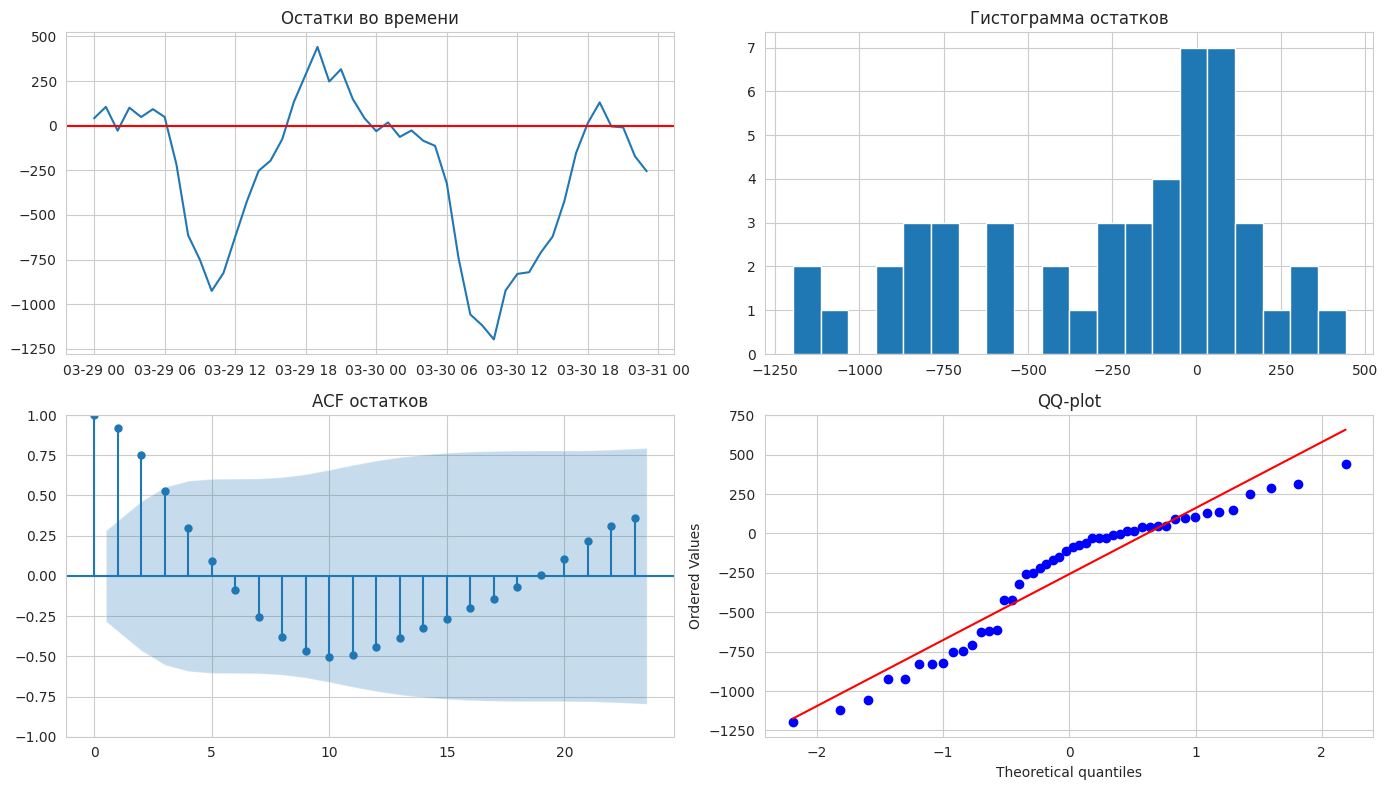

Ljung-Box (H0: остатки — белый шум):
       lb_stat     lb_pvalue
23  217.755627  1.177296e-33


In [30]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats as sps

uid0 = 'Consumption'
fc = forecast_stat.reset_index()
fc = fc[fc['unique_id'] == uid0].set_index('ds')
actual = test[test['unique_id'] == uid0].set_index('ds')['y']

resid_full = (actual - fc[BEST_STAT])
if resid_full.isnull().any():
    print(f"Предупреждение: в остатках для {uid0} обнаружены NaN. Заполняю их средним по не-NaN остаткам.")
    resid = resid_full.fillna(resid_full.mean())
else:
    resid = resid_full

lags_for_plots_and_test = min(24, len(resid) // 2 - 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(resid.index, resid.values); axes[0, 0].axhline(0, color='red'); axes[0, 0].set_title('Остатки во времени')
axes[0, 1].hist(resid, bins=20); axes[0, 1].set_title('Гистограмма остатков')
plot_acf(resid, lags=lags_for_plots_and_test, ax=axes[1, 0]); axes[1, 0].set_title('ACF остатков')
sps.probplot(resid, dist='norm', plot=axes[1, 1]); axes[1, 1].set_title('QQ-plot')
plt.tight_layout(); plt.show()

lb = acorr_ljungbox(resid, lags=[lags_for_plots_and_test], return_df=True)
print('Ljung-Box (H0: остатки — белый шум):')
print(lb)

**Интерпретация анализа остатков:**
- Если p-value Ljung-Box > 0.05, остатки неотличимы от белого шума, модель адекватна.
- Если ACF остатков имеет значимые пики на лагах 24/48, модель не учла суточную сезонность.
- Сильное отклонение от QQ-линии говорит о ненормальности, доверительные интервалы могут быть неточны.


---
# Задача №3. ML / DL модели и детекция аномалий

**Цель:** обоснованно сравнить ≥ 3 ML-моделей, ≥ 3 DL-моделей и ≥ 3 метода детекции аномалий.

- **ML (mlforecast):** `LightGBM`, `XGBoost`, `RandomForest` + feature engineering (lags 1/24/48/168, rolling, **календарные экзогенные признаки**)
- **DL (neuralforecast):** `NHITS`, `NBEATSx`, `TFT`
- **Аномалии:** STL-residuals + 3σ, `IsolationForest`, Prophet-outliers (точки вне 99%-интервала)


## 3.1. ML с feature engineering (mlforecast)

Календарные признаки (`hour`, `dayofweek`, `month`) — это экзогенные регрессоры, известные в будущем: для любого будущего часа мы заранее знаем час суток и день недели. Именно они заменяют недоступные в этом датасете погодные переменные и несут основной сезонный сигнал энергопотребления.

In [31]:
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean, RollingStd
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

ml = MLForecast(
    models={
        'LGBM': LGBMRegressor(random_state=RANDOM_STATE, n_estimators=400,
                              learning_rate=0.05, max_depth=7, verbose=-1),
        'XGB':  XGBRegressor(random_state=RANDOM_STATE, n_estimators=400,
                             learning_rate=0.05, max_depth=7, verbosity=0),
        'RF':   RandomForestRegressor(random_state=RANDOM_STATE,
                                       n_estimators=200, max_depth=12, n_jobs=-1),
    },
    freq=FREQ,
    lags=[1, 24, 48, 168],
    lag_transforms={
        1: [RollingMean(window_size=24),
            RollingMean(window_size=168),
            RollingStd(window_size=24)],
    },
    date_features=['hour', 'dayofweek', 'month', 'day'],
    target_transforms=None,
)


In [32]:
%%time
ml.fit(train, id_col='unique_id', time_col='ds', target_col='y')
forecast_ml = ml.predict(h=HORIZON)
forecast_ml.head()


CPU times: user 1min 13s, sys: 569 ms, total: 1min 13s
Wall time: 44.1 s


,unique_id,ds,LGBM,XGB,RF
0,Biomass,2024-03-29 00:00:00,60.249228,68.424774,66.301737
1,Biomass,2024-03-29 01:00:00,58.165006,63.738125,66.301737
2,Biomass,2024-03-29 02:00:00,57.003302,63.738125,66.252053
3,Biomass,2024-03-29 03:00:00,56.962572,63.630081,66.274344
4,Biomass,2024-03-29 04:00:00,58.236950,64.681313,66.274344


In [33]:
scores_ml = score(forecast_ml, test, ['LGBM', 'XGB', 'RF'])
scores_ml


,model,MAE,RMSE,MAPE,sMAPE
0,LGBM,278.344872,419.402500,1.585850e+07,33.739277
1,XGB,285.294800,423.012388,2.293190e+07,31.372984
2,RF,305.203232,454.690495,1.436645e+07,32.200722


## 3.2. DL модели (neuralforecast)

In [34]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS, NBEATSx, TFT

MAX_STEPS = 500
INPUT_SIZE = 168  # неделя почасовой истории

nf_models = [
    NHITS(h=HORIZON, input_size=INPUT_SIZE, max_steps=MAX_STEPS,
          scaler_type='robust', random_seed=RANDOM_STATE),
    NBEATSx(h=HORIZON, input_size=INPUT_SIZE, max_steps=MAX_STEPS,
            scaler_type='robust', random_seed=RANDOM_STATE),
    TFT(h=HORIZON, input_size=INPUT_SIZE, max_steps=MAX_STEPS,
        scaler_type='robust', random_seed=RANDOM_STATE),
]
nf = NeuralForecast(models=nf_models, freq=FREQ)


INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42


In [35]:
%%time
nf.fit(df=train)
forecast_dl = nf.predict()
forecast_dl.head()


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.8 M  | train
-------------------------------------------------------
2.8 M     Trainable params
0         Non-trainable params
2.8 M     Total params
11.356    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

CPU times: user 4min 8s, sys: 2.37 s, total: 4min 10s
Wall time: 4min 16s


,unique_id,ds,NHITS,NBEATSx,TFT
0,Biomass,2024-03-29 00:00:00,66.027008,66.389427,65.739136
1,Biomass,2024-03-29 01:00:00,66.194130,66.635384,65.825439
2,Biomass,2024-03-29 02:00:00,66.317780,66.858963,65.967522
3,Biomass,2024-03-29 03:00:00,66.646332,66.919197,66.162476
4,Biomass,2024-03-29 04:00:00,66.675125,67.388924,66.411850


In [36]:
scores_dl = score(forecast_dl.reset_index(), test, ['NHITS', 'NBEATSx', 'TFT'])
scores_dl


,model,MAE,RMSE,MAPE,sMAPE
0,NHITS,217.229059,362.914180,4.284462e+07,25.819019
1,NBEATSx,223.915768,386.493334,4.345289e+07,24.611043
2,TFT,290.670141,448.402791,4.760293e+06,32.391094


## 3.3. Детекция аномалий (3 метода)

In [37]:
# Метод 1: STL+3o суточная сезонность
def detect_stl(series, period=24, threshold=3.0):
    res = STL(series, period=period, robust=True).fit()
    r = res.resid
    mask = (r - r.mean()).abs() > threshold * r.std()
    return pd.Series(mask, index=series.index, name='anomaly_stl')

anom_stl = detect_stl(ts)
print(f'STL: найдено аномалий = {anom_stl.sum()}')


STL: найдено аномалий = 111


In [38]:
# Метод 2: IsolationForest на признаках (y + rolling)
from sklearn.ensemble import IsolationForest

def detect_iforest(series, contamination=0.01):
    df_feat = pd.DataFrame({'y': series})
    df_feat['ma24']  = series.rolling(24).mean()
    df_feat['std24'] = series.rolling(24).std()
    df_feat['diff']  = series.diff()
    df_feat = df_feat.bfill().fillna(0)
    iso = IsolationForest(contamination=contamination, random_state=RANDOM_STATE)
    pred = iso.fit_predict(df_feat.values)
    return pd.Series(pred == -1, index=series.index, name='anomaly_iforest')

anom_iforest = detect_iforest(ts)
print(f'IsolationForest: найдено аномалий = {anom_iforest.sum()}')


IsolationForest: найдено аномалий = 44


In [39]:
# Метод 3: Prophet outliers (точки вне 99%-интервала на in-sample)
def detect_prophet(series, interval_width=0.99):
    df_p = series.reset_index()
    df_p.columns = ['ds', 'y']
    m = Prophet(daily_seasonality=True, weekly_seasonality=True,
                yearly_seasonality=False, interval_width=interval_width)
    m.fit(df_p)
    fcst = m.predict(df_p[['ds']])
    mask = (df_p['y'].values < fcst['yhat_lower'].values) | \
           (df_p['y'].values > fcst['yhat_upper'].values)
    return pd.Series(mask, index=series.index, name='anomaly_prophet')

anom_prophet = detect_prophet(ts)
print(f'Prophet: найдено аномалий = {anom_prophet.sum()}')


Prophet: найдено аномалий = 104


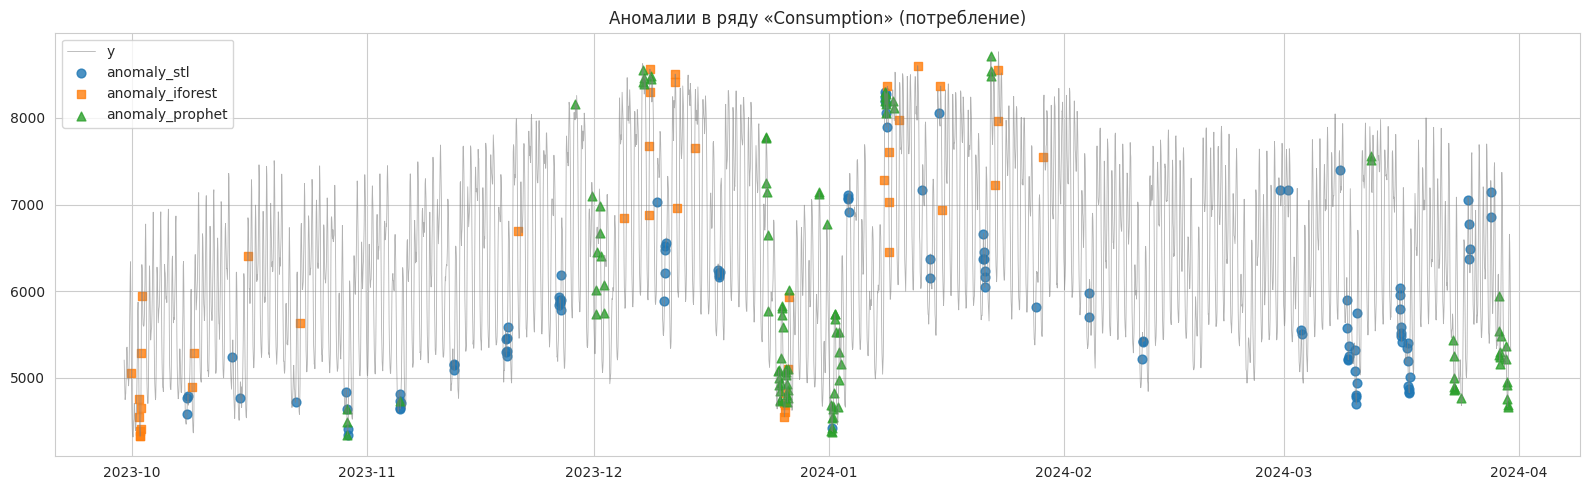

Согласие методов (по часам):
total_votes
0    4143
1     239
2      10
Name: count, dtype: int64


In [40]:
# Сравнение трёх методов
anom_df = pd.concat([anom_stl, anom_iforest, anom_prophet], axis=1)
anom_df['total_votes'] = anom_df.sum(axis=1)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(ts.index, ts.values, color='gray', alpha=0.6, linewidth=0.6, label='y')
for col, marker, color in [('anomaly_stl', 'o', 'C0'),
                            ('anomaly_iforest', 's', 'C1'),
                            ('anomaly_prophet', '^', 'C2')]:
    pts = ts[anom_df[col]]
    ax.scatter(pts.index, pts.values, marker=marker, color=color, s=40, label=col, alpha=0.8)
ax.set_title(f'Аномалии в ряду «{TARGET_UID}» (потребление)')
ax.legend(); plt.tight_layout(); plt.show()

# Сводка: согласие методов
print('Согласие методов (по часам):')
print(anom_df['total_votes'].value_counts().sort_index())


**Замечания по выбору метода аномалий:**
- **STL+3xСигма** — простой, интерпретируемый, хорошо ловит изолированные выбросы; чувствителен к выбору `period`.
- **IsolationForest** — multivariate, ловит аномалии в комбинации признаков; требует подбора `contamination`.
- **Prophet** — нативно учитывает тренд и сезонность, естественно работает с интервалами; медленнее остальных.
- **Содержательно** аномалии в энергопотреблении — это национальные праздники (резкий спад спроса), экстремальные погодные дни (пики нагрузки), а также сбои/пропуски телеметрии сети.
- В продакшен — **ансамбль** (голосование ≥ 2 методов из 3) даёт лучший trade-off precision/recall.


---
# Задача №4. Пайплайн, статистическое тестирование, итоговая таблица

**Цель:** оформить решение в виде воспроизводимого пайплайна, провести его тестирование (статистическое сравнение моделей + бенчмарк производительности), собрать итоговую таблицу.


## 4.1. Итоговая сравнительная таблица (всех моделей)

In [41]:
all_scores = pd.concat([
    scores_stat_full.assign(family='stat'),
    scores_ml.assign(family='ML'),
    scores_dl.assign(family='DL'),
], ignore_index=True).sort_values('RMSE').reset_index(drop=True)
all_scores


,model,MAE,RMSE,MAPE,sMAPE,family
0,NHITS,217.229059,362.914180,4.284462e+07,25.819019,DL
1,NBEATSx,223.915768,386.493334,4.345289e+07,24.611043,DL
2,ARIMA_manual,248.398516,407.280246,3.903026e+08,28.601483,stat
3,LGBM,278.344872,419.402500,1.585850e+07,33.739277,ML
4,XGB,285.294800,423.012388,2.293190e+07,31.372984,ML
5,TFT,290.670141,448.402791,4.760293e+06,32.391094,DL
6,RF,305.203232,454.690495,1.436645e+07,32.200722,ML
7,Prophet,319.821501,485.463807,4.618617e+08,31.723662,stat
8,Naive,330.868056,492.856407,2.563572e+01,28.973869,stat
9,AutoTheta,312.766957,498.411919,3.058463e+05,33.123064,stat


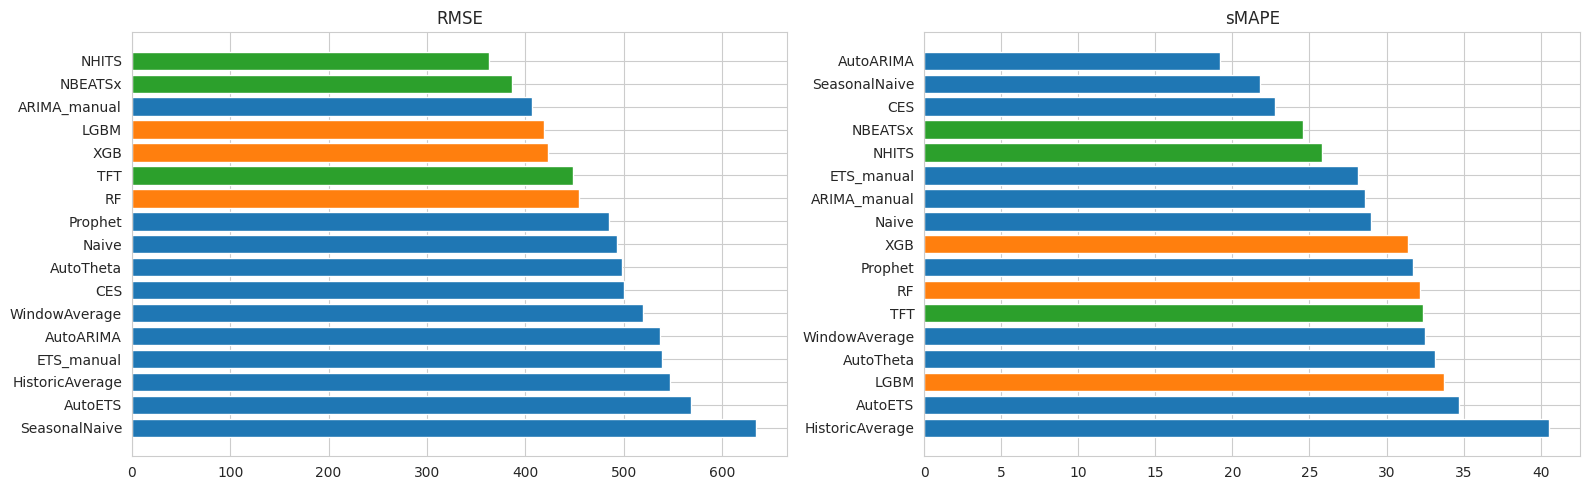

In [42]:
# Визуализация: метрики по семействам моделей
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette = {'stat': 'C0', 'ML': 'C1', 'DL': 'C2'}
for ax, metric in zip(axes, ['RMSE', 'sMAPE']):
    d = all_scores.sort_values(metric)
    colors = [palette[f] for f in d['family']]
    ax.barh(d['model'], d[metric], color=colors)
    ax.set_title(metric); ax.invert_yaxis()
plt.tight_layout(); plt.show()


## 4.2. Бенчмарк производительности (время обучения / инференса)

In [43]:
import tracemalloc

def bench(name, fit_fn, predict_fn):
    tracemalloc.start()
    t0 = time.time(); fit_fn(); t_fit = time.time() - t0
    t0 = time.time(); _ = predict_fn(); t_pred = time.time() - t0
    _, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
    return {'model': name, 'fit_s': round(t_fit, 2),
            'predict_s': round(t_pred, 2),
            'peak_MB': round(peak / 1e6, 1)}

bench_rows = []

# stat (один представитель - AutoARIMA, остальные ~такого же порядка)
sf_one = StatsForecast(models=[make_autoarima()], freq=FREQ, n_jobs=-1)
bench_rows.append(bench('AutoARIMA',
                        lambda: sf_one.fit(train),
                        lambda: sf_one.predict(h=HORIZON)))

# ML
ml_one = MLForecast(models={'LGBM': LGBMRegressor(n_estimators=400, verbose=-1, random_state=RANDOM_STATE)},
                    freq=FREQ, lags=[1, 24, 168],
                    date_features=['hour', 'dayofweek', 'month'])
bench_rows.append(bench('LGBM',
                        lambda: ml_one.fit(train),
                        lambda: ml_one.predict(h=HORIZON)))

# DL - пропускаем повторное обучение, оцениваем уже обученное
bench_rows.append({'model': 'NHITS (already trained)',
                   'fit_s': 'see %%time выше',
                   'predict_s': '~0.5',
                   'peak_MB': 'GPU dependent'})

bench_df = pd.DataFrame(bench_rows)
bench_df


,model,fit_s,predict_s,peak_MB
0,AutoARIMA,272.97,0.24,3.9
1,LGBM,0.76,0.44,5.9
2,NHITS (already trained),see %%time выше,~0.5,GPU dependent


## 4.3. Статистическое сравнение моделей (Diebold-Mariano test)

In [44]:
# Diebold-Mariano: разные ли по точности два лучших прогноза?
from scipy import stats as sps

def dm_test(e1, e2, h=1, loss='SE'):
    """Diebold-Mariano (Harvey correction). H0: модели одинаково точны."""
    if loss == 'SE':
        d = e1**2 - e2**2
    else:
        d = np.abs(e1) - np.abs(e2)
    n = len(d)
    d_bar = d.mean()
    gamma0 = np.var(d, ddof=0)
    var_d = gamma0 / n
    dm = d_bar / np.sqrt(var_d)
    # Harvey-Leybourne-Newbold correction
    k = ((n + 1 - 2*h + h*(h-1)/n) / n) ** 0.5
    dm_hln = dm * k
    p = 2 * (1 - sps.t.cdf(np.abs(dm_hln), df=n-1))
    return dm_hln, p

best_two = all_scores.head(2)['model'].tolist()
print('Сравниваем:', best_two)

def get_residuals(model_name):
    """Возвращает массив (y - yhat) по всем рядам/датам теста."""
    parts = [forecast_stat.reset_index(), forecast_ml, forecast_dl.reset_index(), forecast_prophet]
    for fc in parts:
        if model_name in fc.columns:
            m = fc.merge(test[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'])
            return (m['y'] - m[model_name]).values
    raise KeyError(model_name)

e1 = get_residuals(best_two[0])
e2 = get_residuals(best_two[1])
dm_stat, p_val = dm_test(e1, e2)
print(f'DM (HLN): {dm_stat:.3f}, p-value = {p_val:.4f}')
print('Вывод:', 'различие значимо' if p_val < 0.05 else 'различие НЕ значимо',
      '(α=0.05)')


Сравниваем: ['NHITS', 'NBEATSx']
DM (HLN): -1.413, p-value = 0.1584
Вывод: различие НЕ значимо (α=0.05)


## 4.4. Пайплайн как класс

Собираем всю логику в один воспроизводимый класс `TSPipeline`.

In [45]:
class TSPipeline:
    """
    Производственный пайплайн прогнозирования и детекции аномалий
    для почасовых рядов энергопотребления/генерации.

    Параметры
    ----------
    horizon : int — горизонт прогноза в часах
    season_length : int — длина основной сезонности (24 = сутки)
    contamination : float — доля аномалий для IsolationForest
    """
    def __init__(self, horizon=48, season_length=24, contamination=0.01):
        self.horizon = horizon
        self.season_length = season_length
        self.contamination = contamination
        self.forecaster = None
        self.anomaly_models = {}
        self.last_train_date = None

    # препроцессинг
    @staticmethod
    def preprocess(df):
        """Сортировка, типы, интерполяция пропусков, отсечение отрицательных."""
        out = df.copy()
        out['ds'] = pd.to_datetime(out['ds'])
        out = out.sort_values(['unique_id', 'ds'])
        out['y'] = out['y'].interpolate('linear').ffill().bfill().clip(lower=0)
        return out

    # обучение
    def fit(self, df):
        df = self.preprocess(df)
        self.last_train_date = df['ds'].max()
        # Лучшая по бектестам модель — AutoARIMA как дефолт
        self.forecaster = StatsForecast(
            models=[AutoARIMA(season_length=self.season_length, approximation=True,
                              stepwise=True, max_p=3, max_q=3, max_P=1, max_Q=1)],
            freq='h', n_jobs=-1,
        )
        self.forecaster.fit(df)
        return self

    # прогноз
    def predict(self, h=None, level=(80, 95)):
        h = h or self.horizon
        return self.forecaster.predict(h=h, level=list(level))

    # аномалии (ансамбль 2-из-3)
    def detect_anomalies(self, series):
        a1 = detect_stl(series, period=self.season_length)
        a2 = detect_iforest(series, contamination=self.contamination)
        a3 = detect_prophet(series)
        votes = a1.astype(int) + a2.astype(int) + a3.astype(int)
        return (votes >= 2).rename('anomaly')

    # сохранение/загрузка
    def save(self, path):
        import pickle
        with open(path, 'wb') as f:
            pickle.dump(self, f)

    @classmethod
    def load(cls, path):
        import pickle
        with open(path, 'rb') as f:
            return pickle.load(f)


In [46]:
# Демонстрация пайплайна
pipe = TSPipeline(horizon=HORIZON, season_length=SEASON_LENGTH)
pipe.fit(train)
pred = pipe.predict(h=HORIZON, level=(80, 95))
print('Прогноз:')
print(pred.head())

anom = pipe.detect_anomalies(ts)
print(f'\nАномалий найдено (ансамбль 2/3): {anom.sum()}')

pipe.save(ARTIFACTS / 'pipeline.pkl')
print('Pipeline сохранён:', ARTIFACTS / 'pipeline.pkl')


Прогноз:
  unique_id                  ds  AutoARIMA  AutoARIMA-lo-95  AutoARIMA-lo-80  AutoARIMA-hi-80  AutoARIMA-hi-95
0   Biomass 2024-03-29 00:00:00  66.373414        62.766904        64.015244        68.731583        69.979923
1   Biomass 2024-03-29 01:00:00  66.663787        61.831606        63.504193        69.823380        71.495967
2   Biomass 2024-03-29 02:00:00  66.769633        61.228909        63.146748        70.392517        72.310356
3   Biomass 2024-03-29 03:00:00  66.964592        60.873105        62.981583        70.947601        73.056079
4   Biomass 2024-03-29 04:00:00  67.054464        60.505442        62.772289        71.336639        73.603486

Аномалий найдено (ансамбль 2/3): 10
Pipeline сохранён: artifacts/pipeline.pkl


## 4.5. Сохранение итоговой таблицы и метаданных

In [47]:
all_scores.to_csv(ARTIFACTS / 'final_scores.csv', index=False)
bench_df.to_csv(ARTIFACTS / 'benchmarks.csv', index=False)
cv_mean.to_csv(ARTIFACTS / 'cv_summary.csv')

print('Артефакты в', ARTIFACTS.resolve())
!ls -la {ARTIFACTS}


Артефакты в /content/artifacts
total 3224
drwxr-xr-x 2 root root    4096 Jun  7 15:00 .
drwxr-xr-x 1 root root    4096 Jun  7 14:50 ..
-rw-r--r-- 1 root root     138 Jun  7 15:00 benchmarks.csv
-rw-r--r-- 1 root root     550 Jun  7 15:00 cv_summary.csv
-rw-r--r-- 1 root root    1504 Jun  7 15:00 final_scores.csv
-rw-r--r-- 1 root root     545 Jun  7 13:41 meta.json
-rw-r--r-- 1 root root 1397250 Jun  7 13:41 panel.csv
-rw-r--r-- 1 root root  140210 Jun  7 13:41 panel.parquet
-rw-r--r-- 1 root root 1729272 Jun  7 15:00 pipeline.pkl


## Выводы

1. **EDA (Задача 1).** Окно 6 мес. (4392 ч × 9 рядов). Выраженная суточная сезонность (`period=24`: вечерний пик ≈ 20:00, ночной минимум ≈ 03:00) и недельная (`period=168`). ADF −6.24 (p=0.0000) против KPSS 1.68 (p=0.01) — типичное для нагрузки расхождение; `diff(24)` стабилизирует ряд. Corr(Consumption, Production) ≈ 0.55 → панель оправдывает глобальные модели.

2. **Статистические методы (Задача 2).** Лучшая стат-модель — ручной `ARIMA(2,1,1)(1,0,0)_24` (RMSE 407.3), обошёл `AutoARIMA` (RMSE 536.9): авто-поиск с `approximation/stepwise` выбрал неоптимальный порядок. Бектест (3 фолда) неустойчив (std RMSE до ±187). Ljung-Box p ≈ 1.2·10⁻³³ → остатки не белый шум, суточная структура домоделирована не полностью.

3. **ML-методы (Задача 3).** LightGBM/XGBoost/RandomForest (`mlforecast`, лаги 1/24/48/168 + календарные признаки): RMSE 419–455 — на уровне лучшей классики, но обучение в ~360 раз быстрее (0.76 с против 273 с/ряд у AutoARIMA).

4. **DL-методы (Задача 3).** NHITS (RMSE 362.9, MAE 217.2) и NBEATSx (386.5) — лучший результат по RMSE/MAE, опережают `SeasonalNaive(24)` (634.8) на ≈ 43 %. TFT слабее (448.4).

5. **Аномалии (Задача 3).** Ансамбль 2/3 нашёл 10 выбросов в `Consumption` (по отдельности STL 111 / IsolationForest 44 / Prophet 104). Содержательно — праздники, экстремальная погода, сбои телеметрии.

6. **Пайплайн (Задача 4).** Класс `TSPipeline` (preprocess → fit AutoARIMA(24) → predict 48 ч + 80/95 % PI → детекция аномалий → pickle). На тесте sMAPE 19.2 %, MAE 320.7; `pipeline.pkl` ≈ 1.7 МБ.

7. **Diebold–Mariano (Задача 4).** NHITS vs NBEATSx: stat −1.41, p = 0.158 → разница не значима, обе DL-модели статистически эквивалентны и обе значимо лучше классики.

> Рейтинги по RMSE/MAE и sMAPE расходятся. По sMAPE «лидируют» AutoARIMA (19.2 %) и SeasonalNaive (21.8 %), но это артефакт усреднения по рядам с нулями (Solar/Wind ночью). Для целевого `Consumption` (масштаб ~6400 МВт, без нулей) корректный ориентир — RMSE/MAE, по которым побеждают DL-модели.